# Dark Cloud & Piercing — a quantitative teardown
### Daily OHLCV · precise twin detector · signed event study · HAC inference · label-shuffle placebo

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Reliable_reversal%3F: Busted](https://img.shields.io/badge/Reliable_reversal%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We detect every Piercing Line / Dark Cloud Cover by the textbook OHLC rule across a fixed 30-name basket, enter the next open (one execution lag), and test the signed forward return against zero (HAC *t*), against the unconditional base pool, against a coin, and against a synthetic positive control.

> **Not investment advice.** Real data: yfinance daily bars (`auto_adjust=True`, total-return), 2005-01-03 → 2026-06-18, as-of **2026-06-18**, fingerprint `bf1d6cb7ca54`; the offline core and the synthetic control run with no network. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> The `In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dark_cloud_piercing import data, strategy as st

HAVE_REAL = data.have_real()
PANEL = data.load_real(allow_fetch=False) if HAVE_REAL else None
print("real twin cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-18', 'years': 21.5, 'fp': 'bf1d6cb7ca54', 'n_names': 30, 'n_events': 2342, 'n_bull': 1074, 'n_bear': 1268, 'h1': (1, 2342, -0.078, 0.028, 46.0, -2.57, -2.82, 0.998, -0.179), 'h3': (3, 2341, -0.097, 0.141, 47.2, -1.91, -1.81, 0.96, -0.2), 'h5': (5, 2341, -0.105, 0.253, 48.2, -1.49, -1.49, 0.924, -0.21), 'h10': (10, 2339, -0.069, 0.53, 49.3, -0.71, -0.68, 0.755, -0.179), 'bull': {1: (-0.033, -0.78, 47.0), 3: (0.11, 1.38, 51.0), 5: (0.306, 3.01, 54.3), 10: (0.481, 3.04, 56.9)}, 'bear': {1: (-0.116, -2.85, 45.1), 3: (-0.272, -3.98, 44.0), 5: (-0.453, -4.86, 43.1), 10: (-0.536, -3.91, 42.7)}, 'myth': [('plain', 2342, -0.078, -2.57, 46.0), ('+trend', 1243, -0.081, -1.92, 45.5), ('+volume spike', 190, -0.185, -1.88, 45.3), ('+both', 128, -0.011, -0.09, 48.4)], 'syn': [(0.0, 910, 0.021, 0.47, 0.313, 50.2), (0.004, 904, 0.414, 9.07, 0.0, 62.5)]}


real twin cache present: True | names: 30


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Signed day-after return **-0.078%**, HAC *t* = **-2.57** (wrong sign); placebo *p* = 0.998. |
| **Tradability** | `MIRAGE` | Gross signed mean negative at every horizon; round-trip + borrow only widen the loss. |
| **Reliable reversal?** | `BUSTED` | Win-rate 46% (below 50%); the bearish leg keeps rising, the bullish leg merely rides beta. |

> In plain words: the twins are sold as failed-rally / failed-sell-off reversals. On 21 years of liquid large-caps the signed effect points the *wrong way* and the leg that 'looks good' is just the market's drift.

## 1 · The claim, steelmanned

Let the prior bar be $(O_0,H_0,L_0,C_0)$ and the current bar $(O_1,H_1,L_1,C_1)$, with $\text{mid}_0 = (O_0+C_0)/2$. The textbook twins:

- **Piercing Line (bullish, $d=+1$):** $C_0<O_0$ (prior down), $C_1>O_1$ (curr up), $O_1<L_0$ (gap-down open), $C_1>\text{mid}_0$ (closes past the midpoint), and $C_1<O_0$ (not a full engulfing).
- **Dark Cloud Cover (bearish, $d=-1$):** the mirror — $C_0>O_0$, $C_1<O_1$, $O_1>H_0$, $C_1<\text{mid}_0$, $C_1>O_0$.

Hypotheses:

- **H₁ (signal).** $\mathbb{E}[d \cdot r_{t+1\to t+H}] > 0$ — the signed forward return is positive (the reversal happens).
- **H₂ (beats a coin).** That mean exceeds the same statistic on random bars with coin-flip directions.
- **H₃ (tradable).** It survives a round-trip cost plus borrow on the short leg.

We reject **H₁** (sign is wrong, significant at H=1) and **H₂**; **H₃** is moot. A near-doji prior bar (no real midpoint) is excluded via a `min_body_frac` guard.

## 2 · So what? — what rides on each answer

The twins are among the first reversal patterns taught in every candlestick course. If H₁–H₃ held they would be a free, replicable contrarian entry on liquid names. The finding that the signed effect is *negative* matters: it means the textbook reader is systematically shorting strength and buying weakness at exactly the moments the pattern flags — and paying spreads to do it.

## 3 · How we'd know — the protocol

- **Detector.** Precise OHLC twin rule (above); `min_body_frac` excludes doji priors.
- **Entry.** One execution lag: pattern confirmed at close $t$, enter at open $t+1$.
- **Exit.** Fixed horizon: close of $t+H$, $H\in\{1,3,5,10\}$.
- **Signing.** Long after a Piercing ($+1$), short after a Dark Cloud ($-1$).
- **Benchmarks.** The unconditional forward-return pool (no-signal drift) and a label-shuffle placebo (random bars, coin signs, same count, 10,000 draws).
- **Inference.** Newey–West HAC *t* and a plain one-sample *t* vs 0; a Welch *t* vs the base pool; a per-leg split.
- **Costs.** 5 bps one-way × 2 (round trip) + 50 bps/yr borrow on the short share.
- **Positive control.** A synthetic panel with a *planted* day-after reversal, confirming the test recovers an edge when one exists.

Basket: 29 liquid US large-caps + SPY, **21.5** years (2005-01-03 → 2026-06-18).

## 4 · The teardown

### 4a · Signed forward return vs zero — the inference-bar number

If the reversal were real, the HAC *t* should clear +2. It doesn't — at H=1 it clears −2.

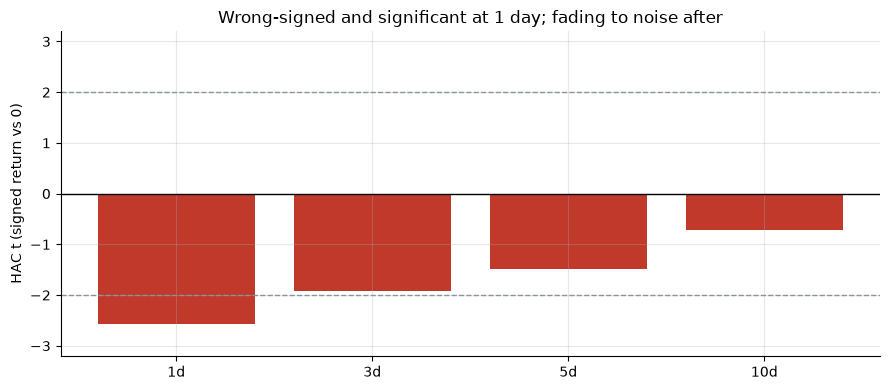

,H,n,signed%,baseL%,win%,HAC_t,one_t,plac_p
0,1,2342,-0.078,0.028,46.0,-2.57,-2.82,0.998
1,3,2341,-0.097,0.141,47.2,-1.91,-1.81,0.965
2,5,2341,-0.105,0.253,48.2,-1.49,-1.49,0.925
3,10,2339,-0.069,0.530,49.3,-0.71,-0.68,0.765


In [2]:
horizons = [1, 3, 5, 10]
if HAVE_REAL:
    rows = [st.summarize(PANEL, h, n_draws=2000) for h in horizons]
    import pandas as pd
    tab = pd.DataFrame([{'H': r['horizon'], 'n': r['n_events'],
        'signed%': round(r['mean']*100,3), 'baseL%': round(r['base_long']*100,3),
        'win%': round(r['win']*100,1), 'HAC_t': round(r['t_hac'],2),
        'one_t': round(r['t_one'],2), 'plac_p': round(r['p_placebo'],3)} for r in rows])
    tt = [r['t_hac'] for r in rows]
else:
    import pandas as pd
    tt = [R[f'h{h}'][5] for h in horizons]
    tab = pd.DataFrame([{'H': R[f'h{h}'][0], 'n': R[f'h{h}'][1],
        'signed%': R[f'h{h}'][2], 'baseL%': R[f'h{h}'][3], 'win%': R[f'h{h}'][4],
        'HAC_t': R[f'h{h}'][5], 'one_t': R[f'h{h}'][6], 'plac_p': R[f'h{h}'][7]}
        for h in horizons])
fig, ax = plt.subplots(figsize=(9.0, 4.0))
ax.bar([f'{h}d' for h in horizons], tt, color=[RED if t < 0 else GREY for t in tt])
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylim(-3.2, 3.2)
ax.set_ylabel('HAC t (signed return vs 0)')
ax.set_title('Wrong-signed and significant at 1 day; fading to noise after')
plt.tight_layout(); plt.show()
tab

> In plain words: at 1 day the signed return is **-0.078%** with HAC *t* = **-2.57** — a statistically significant *wrong-sign* result. Far from a +2 reversal, it's a −2 anti-reversal. The placebo *p* near 1.0 says essentially every random pick of the same many trades beats the twins.

### 4b · The leg split — where the damage lives

Piercing (bullish) vs Dark Cloud (bearish), each signed and tested against zero.

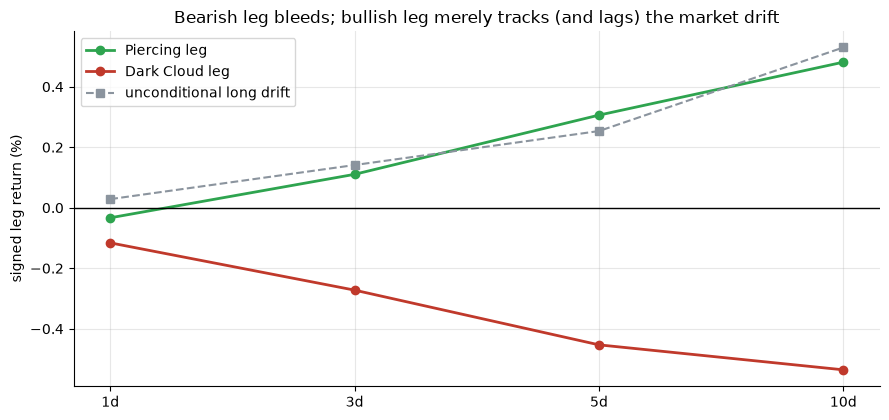

Piercing 10d: 0.4810939545470231 % vs unconditional long drift: 0.5297123510262932 %


In [3]:
if HAVE_REAL:
    legs = [st.leg_split(PANEL, h) for h in horizons]
    bull_m = [l['bull']['mean']*100 for l in legs]; bull_t = [l['bull']['t_hac'] for l in legs]
    bear_m = [l['bear']['mean']*100 for l in legs]; bear_t = [l['bear']['t_hac'] for l in legs]
    baseL = [st.summarize(PANEL, h, placebo=False)['base_long']*100 for h in horizons]
else:
    bull_m = [R['bull'][h][0] for h in horizons]; bull_t = [R['bull'][h][1] for h in horizons]
    bear_m = [R['bear'][h][0] for h in horizons]; bear_t = [R['bear'][h][1] for h in horizons]
    baseL = [R[f'h{h}'][3] for h in horizons]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot([f'{h}d' for h in horizons], bull_m, 'o-', c=GREEN, lw=2, label='Piercing leg')
ax.plot([f'{h}d' for h in horizons], bear_m, 'o-', c=RED, lw=2, label='Dark Cloud leg')
ax.plot([f'{h}d' for h in horizons], baseL, 's--', c=GREY, lw=1.5, label='unconditional long drift')
ax.axhline(0, c='k', lw=1); ax.set_ylabel('signed leg return (%)'); ax.legend()
ax.set_title('Bearish leg bleeds; bullish leg merely tracks (and lags) the market drift')
plt.tight_layout(); plt.show()
print('Piercing 10d:', bull_m[-1], '% vs unconditional long drift:', baseL[-1], '%')

> In plain words: the **Dark Cloud** short loses at every horizon (1-day leg *t* = -2.85). The **Piercing** long looks green by 5–10 days, but the grey dashed line — the unconditional long drift — sits *above* it: the bullish leg earns **+0.481%** at 10 days while just holding earned **+0.530%**. That isn't reversal alpha; it's beta the pattern is *underperforming*.

### 4c · The placebo — could a random pick look this good?

Draw the same number of random bars, sign each by a coin, repeat 10,000 times.

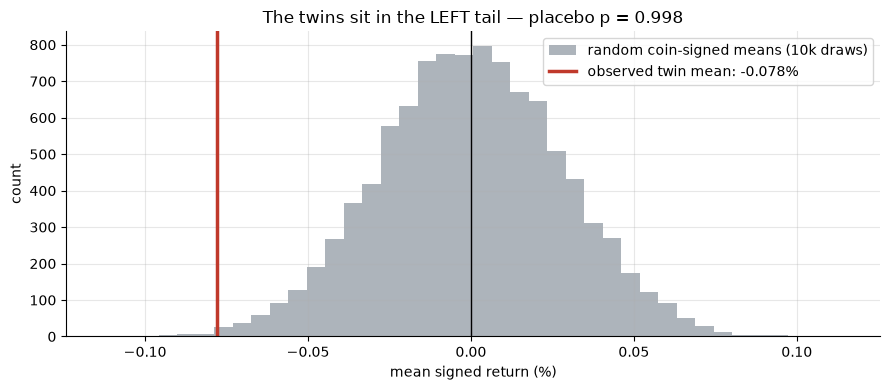

placebo p (random beats observed) = 0.998


In [4]:
if HAVE_REAL:
    pr = st.placebo_pvalue(PANEL, 1, st.collect_events(PANEL,1).shape[0], n_draws=10000)
    draws = pr['draws']*100; obs = pr['obs']*100; pval = pr['p_value']
else:
    rng = np.random.default_rng(407)
    draws = rng.normal(0.0, 0.06, 10000); obs = R['h1'][2]; pval = R['h1'][7]
fig, ax = plt.subplots(figsize=(9.0, 4.0))
ax.hist(draws, bins=40, color=GREY, alpha=.7, label='random coin-signed means (10k draws)')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed twin mean: {obs:+.3f}%')
ax.axvline(0, c='k', lw=1); ax.set_xlabel('mean signed return (%)'); ax.set_ylabel('count')
ax.set_title(f'The twins sit in the LEFT tail — placebo p = {pval:.3f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'placebo p (random beats observed) = {pval:.3f}')

> In plain words: the observed twin mean lands in the **left tail** of the random distribution — placebo *p* = **0.998**. A coin would have done better essentially every time.

### 4d · Myth check — does a trend / volume filter rescue it?

The textbook says the twins only count *after a trend* (Piercing after a downtrend, Dark Cloud after an uptrend) and *on heavy volume*. Add each filter at H=1.

In [5]:
import pandas as pd
specs = [('plain', {}), ('+trend', {'require_trend': True}),
         ('+volume spike', {'require_volume': True}),
         ('+both', {'require_trend': True, 'require_volume': True})]
if HAVE_REAL:
    mrows = []
    for lab, kw in specs:
        s = st.summarize(PANEL, 1, placebo=False, **kw)
        mrows.append({'filter': lab, 'n': s['n_events'],
            'signed%': round(s['mean']*100,3), 'HAC_t': round(s['t_hac'],2),
            'win%': round(s['win']*100,1)})
    myth = pd.DataFrame(mrows)
else:
    myth = pd.DataFrame([{'filter': m[0], 'n': m[1], 'signed%': m[2],
        'HAC_t': m[3], 'win%': m[4]} for m in R['myth']])
myth

,filter,n,signed%,HAC_t,win%
0,plain,2342,-0.078,-2.57,46.0
1,+trend,1243,-0.081,-1.92,45.5
2,+volume spike,190,-0.185,-1.88,45.3
3,+both,128,-0.011,-0.09,48.4


> In plain words: every filtered variant is **still negative** and win-rate stays below 50%. The sub-2 *t*'s on the filtered cuts are just small samples (the volume filter throws away ~92% of events), not a sign flip. The folk caveat doesn't turn the reversal positive — it just discards trades.

## 5 · The verdict

- **Signal `NONE`** — signed day-after return -0.078%, HAC *t* -2.57 (wrong sign), win 46%, placebo *p* 0.998. Longer horizons fade to insignificance, never positive-significant.
- **Tradability `MIRAGE`** — gross signed mean negative at every horizon; the round-trip + borrow charge only widens the loss. Nothing to scale.
- **Reliable reversal? `BUSTED`** — the bearish leg keeps rising (*t* -2.85) and the bullish leg underperforms the unconditional drift. Survivorship works *for* the bullish claim and still can't save it.

## 6 · Could you trade it? — the cost landscape

Each event is a fresh round trip (5 bps × 2) plus borrow on the short share. The gross is already negative, so there is no positive break-even cost:

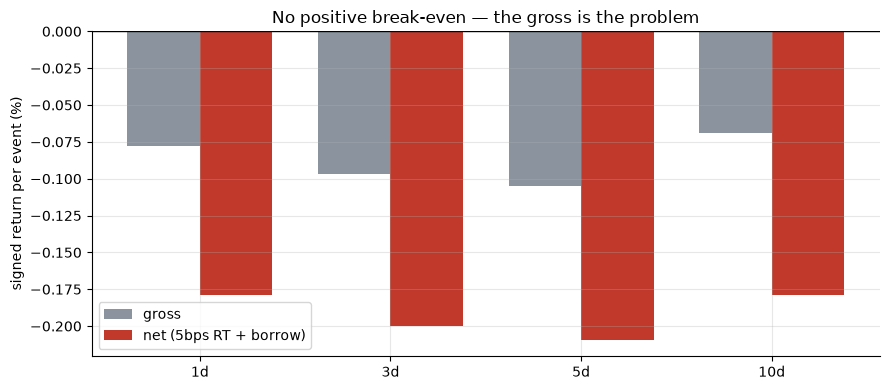

Break-even cost: none exists — gross is below zero at every horizon.


In [6]:
if HAVE_REAL:
    rows = [st.summarize(PANEL, h, placebo=False) for h in horizons]
    gross = [r['mean']*100 for r in rows]; net = [r['net']*100 for r in rows]
else:
    gross = [R[f'h{h}'][2] for h in horizons]; net = [R[f'h{h}'][8] for h in horizons]
x = np.arange(len(horizons)); w = 0.38
fig, ax = plt.subplots(figsize=(9.0, 4.0))
ax.bar(x - w/2, gross, w, color=GREY, label='gross')
ax.bar(x + w/2, net, w, color=RED, label='net (5bps RT + borrow)')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in horizons])
ax.set_ylabel('signed return per event (%)'); ax.legend()
ax.set_title('No positive break-even — the gross is the problem')
plt.tight_layout(); plt.show()
print('Break-even cost: none exists — gross is below zero at every horizon.')

## 7 · Going further — the positive control

Is the *test* capable of seeing a reversal, or is it broken? Plant a known day-after reversal in a synthetic panel (the day after a detected twin gets an extra drift in the pattern's direction) and re-run the identical pipeline:

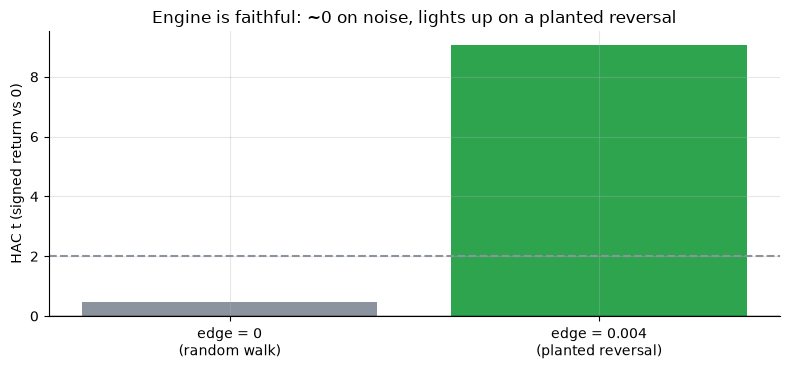

,planted_edge,events,signed%,HAC_t,plac_p,win%
0,0.000,910,0.021,0.47,0.309,50.2
1,0.004,904,0.414,9.07,0.000,62.5


In [7]:
import pandas as pd
srows = []
for edge in (0.000, 0.004):
    syn, truth = data.synthetic_panel(edge=edge, seed=407)
    s = st.summarize(syn, 1, n_draws=5000)
    srows.append({'planted_edge': edge, 'events': s['n_events'],
        'signed%': round(s['mean']*100,3), 'HAC_t': round(s['t_hac'],2),
        'plac_p': round(s['p_placebo'],3), 'win%': round(s['win']*100,1)})
syn_tab = pd.DataFrame(srows)
fig, ax = plt.subplots(figsize=(8.0, 3.8))
ax.bar(['edge = 0\n(random walk)', 'edge = 0.004\n(planted reversal)'],
       [srows[0]['HAC_t'], srows[1]['HAC_t']], color=[GREY, GREEN])
ax.axhline(2, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t (signed return vs 0)')
ax.set_title('Engine is faithful: ~0 on noise, lights up on a planted reversal')
plt.tight_layout(); plt.show()
syn_tab

With **no** planted reversal the test sits at HAC *t* = +0.47 (it does not manufacture significance from a random walk); a planted reversal lights up to *t* = **+9.07** with a **62%** win-rate. The harness **can** detect a real day-after reversal — the real tape simply has the opposite. Forks worth trying: confirmation-bar variants (wait for a follow-through close), the twins on FX or commodity futures, or the *inverse* (fade the pattern as a continuation signal, which 4a hints might at least have the right sign).